[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/geo-di-lab/emerge-lessons/blob/main/docs/ch1/lesson6.ipynb)

# Introducción a los datos de GLOBE
Examinaremos dos conjuntos de datos de GLOBE: [Mosquito Habitat Mapper](https://observer.globe.gov/do-globe-observer/mosquito-habitats) y [Land Cover](https://observer.globe.gov/do-globe-observer/land-cover).

Puedes ver un [panel interactivo de estos datos](https://experience.arcgis.com/experience/15c3e38176ec44d1a2f250c218343b4b).

Puedes ejecutar el siguiente código con Google Colab, que funciona en tu navegador (no requiere instalaciones).

Primero, cargaremos los paquetes de Python, que nos dan más opciones para trabajar con nuestro código.

In [2]:
import pandas as pd                           # Para trabajar con datos
pd.set_option("display.max_columns", None)    # Nos permite ver todas las columnas de los datos en lugar de solo una vista previa
import geopandas as gpd                       # Para trabajar con datos espaciales
import numpy as np                            # Para trabajar con números
import matplotlib.pyplot as plt               # Para crear gráficos
from datetime import date                     # Para dar formato a las fechas
from PIL import Image                         # Para obtener y mostrar imágenes desde enlaces
import requests                               # Para obtener información desde enlaces
from io import BytesIO                        # Para trabajar con tipos de entrada y salida

In [3]:
end_date = "2024-12-31"

## Mosquito Habitat Mapper

Usemos la [API de GLOBE](https://www.globe.gov/globe-data/globe-api), que nos permite obtener los datos directamente sin necesidad de descargar nada.

In [4]:
data = gpd.read_file(f"https://api.globe.gov/search/v1/measurement/?protocols=mosquito_habitat_mapper&datefield=measuredDate&startdate=2018-01-01&enddate={end_date}&geojson=TRUE&sample=FALSE")

Si obtienes el error `NameError: name 'gpd' is not defined`, ve al inicio de este cuaderno y haz clic en la flecha junto al primer bloque de código que empieza con `import geopandas as gpd`. Esto instalará los paquetes necesarios para el resto del código.

Observa las primeras 10 filas de los datos, que son las entradas más recientes enviadas a la app GLOBE Observer.

In [5]:
data.head(10)

,countryCode,countryName,elevation,mosquitohabitatmapperAbdomenCloseupPhotoUrls,mosquitohabitatmapperBreedingGroundEliminated,mosquitohabitatmapperComments,mosquitohabitatmapperDataSource,mosquitohabitatmapperExtraData,mosquitohabitatmapperGenus,mosquitohabitatmapperGlobeTeams,mosquitohabitatmapperLarvaFullBodyPhotoUrls,mosquitohabitatmapperLarvaeCount,mosquitohabitatmapperLastIdentifyStage,mosquitohabitatmapperLocationAccuracyM,mosquitohabitatmapperLocationMethod,mosquitohabitatmapperMeasuredAt,mosquitohabitatmapperMeasurementElevation,mosquitohabitatmapperMeasurementLatitude,mosquitohabitatmapperMeasurementLongitude,mosquitohabitatmapperMosquitoAdults,mosquitohabitatmapperMosquitoEggCount,mosquitohabitatmapperMosquitoEggs,mosquitohabitatmapperMosquitoHabitatMapperId,mosquitohabitatmapperMosquitoPupae,mosquitohabitatmapperSpecies,mosquitohabitatmapperUserid,mosquitohabitatmapperWaterSource,mosquitohabitatmapperWaterSourcePhotoUrls,mosquitohabitatmapperWaterSourceType,organizationId,organizationName,protocol,siteId,siteName,geometry
0,BRA,Brazil,6.3,null,false,null,GLOBE Observer App,LarvaeVisibleNo,null,[COLUNSLZ],null,0,null,13,automatic,2024-12-31 17:16:00,0,-2.5617,-44.2657,null,null,null,46287,false,null,137422629,ovitrap,https://data.globe.gov/system/photos/2024/12/3...,container: artificial,17459532,Brazil Citizen Science,mosquito_habitat_mapper,371514,23MNT816168,POINT (-44.26597 -2.56197)
1,BRA,Brazil,6.3,null,false,null,GLOBE Observer App,LarvaeVisibleNo,null,[COLUNSLZ],null,0,null,13,automatic,2024-12-31 17:20:00,0,-2.5617,-44.2657,null,null,null,46290,false,null,137422629,ovitrap,https://data.globe.gov/system/photos/2024/12/3...,container: artificial,17459532,Brazil Citizen Science,mosquito_habitat_mapper,371514,23MNT816168,POINT (-44.26597 -2.56197)
2,BRA,Brazil,7.4,null,true,null,GLOBE Observer App,LarvaeVisibleNo,null,[COLUNSLZ],null,0,null,51,automatic,2024-12-31 22:32:00,0,-2.5163,-44.3023,null,null,null,46482,false,null,137420190,"cement, metal or plastic tank",null,container: artificial,17459532,Brazil Citizen Science,mosquito_habitat_mapper,372864,23MNT775218,POINT (-44.30288 -2.51676)
3,BRA,Brazil,20.6,null,true,null,GLOBE Observer App,LarvaeVisibleNo,null,[COLUNSLZ],null,0,null,66,automatic,2024-12-31 00:05:00,0,-2.8639,-44.0549,null,null,null,46203,false,null,137419937,can or bottle,null,container: artificial,17459532,Brazil Citizen Science,mosquito_habitat_mapper,373085,23MPS050834,POINT (-44.05526 -2.86396)
4,BRA,Brazil,20.6,null,true,null,GLOBE Observer App,LarvaeVisibleNo,null,[COLUNSLZ],null,0,null,28,automatic,2024-12-31 00:23:00,0,-2.8639,-44.055,null,null,null,46223,false,null,137419937,lake,null,still: lake/pond/swamp,17459532,Brazil Citizen Science,mosquito_habitat_mapper,373085,23MPS050834,POINT (-44.05526 -2.86396)
5,BRA,Brazil,20.6,null,true,null,GLOBE Observer App,LarvaeVisibleNo,null,[COLUNSLZ],null,0,null,19,automatic,2024-12-31 00:26:00,0,-2.8639,-44.055,null,null,null,46230,false,null,137419937,"plant husk (areca, coconut etc)",null,container: natural,17459532,Brazil Citizen Science,mosquito_habitat_mapper,373085,23MPS050834,POINT (-44.05526 -2.86396)
6,BRA,Brazil,20.6,null,true,null,GLOBE Observer App,LarvaeVisibleNo,null,[COLUNSLZ],null,0,null,98,automatic,2024-12-31 00:31:00,0,-2.8638,-44.0548,null,null,null,46234,false,null,137419937,lake,null,still: lake/pond/swamp,17459532,Brazil Citizen Science,mosquito_habitat_mapper,373085,23MPS050834,POINT (-44.05526 -2.86396)
7,BRA,Brazil,20.6,null,true,null,GLOBE Observer App,LarvaeVisibleNo,null,[COLUNSLZ],null,0,null,98,automatic,2024-12-31 00:42:00,0,-2.8638,-44.0552,null,null,null,46261,false,null,137419937,plant clumps (bamboo etc),null,container: natural,17459532,Brazil Citizen Science,mosquito_habitat_mapper,373085,23MPS050834,POINT (-44.05526 -2.86396)
8,BRA,Brazil,20.6,null,true,null,GLOBE Observer App,LarvaeVisibleNo,null,[COLUNSLZ],null,0,null,100,automatic,2024-12-31 00:46:00,0,-2.8639,-44.0552,null,null,null,46264,false,null,137

Usemos la función `info()` para conocer más sobre lo que contiene el conjunto de datos.

In [6]:
data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 43345 entries, 0 to 43344
Data columns (total 35 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   countryCode                                    43259 non-null  object        
 1   countryName                                    43259 non-null  object        
 2   elevation                                      43345 non-null  object        
 3   mosquitohabitatmapperAbdomenCloseupPhotoUrls   43345 non-null  object        
 4   mosquitohabitatmapperBreedingGroundEliminated  43345 non-null  object        
 5   mosquitohabitatmapperComments                  43345 non-null  object        
 6   mosquitohabitatmapperDataSource                43345 non-null  object        
 7   mosquitohabitatmapperExtraData                 43345 non-null  object        
 8   mosquitohabitatmapperGenus                     4

Vemos información sobre cada columna: cuántas filas no nulas hay (no nulo significa que no falta el valor) y el tipo (un dtype "object" significa que es texto). Vemos que también tenemos una columna `datetime`, que sería ideal para analizar los datos a lo largo del tiempo. La columna `geometry` nos da información sobre el lugar donde el científico ciudadano recolectó los datos sobre los mosquitos.

Sin embargo, hay algunas columnas que actualmente están almacenadas como "object" cuando queremos que se almacenen como "float" (decimal) o "int" (número entero). Además, en algunas filas, si el valor falta, aparece la palabra "null", que puede confundirse con un valor real. La reemplazaremos con NAN, que Python interpreta como vacío en lugar de como un objeto.

Nota: La columna 'mosquitohabitatmapperLarvaeCount' almacena números además de rangos como 1-25. Sin embargo, necesitamos simplificar estos rangos a un solo número para que sean más fáciles de almacenar en el conjunto de datos y más consistentes. Así que, si hay un rango, lo reemplazaremos con el valor inferior del rango.

In [7]:
# Quitemos el "mosquitomapper" del inicio de todos los nombres de columna para verlos más fácilmente
new_column_names = data.columns.str.replace("mosquitohabitatmapper", "")

# Pon en mayúscula la primera letra de cada nombre de columna (por consistencia), excepto en geometry
new_column_names = [name[0].upper() + name[1:] if name != 'geometry' else name for name in new_column_names]

data.columns = new_column_names
data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 43345 entries, 0 to 43344
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   CountryCode               43259 non-null  object        
 1   CountryName               43259 non-null  object        
 2   Elevation                 43345 non-null  object        
 3   AbdomenCloseupPhotoUrls   43345 non-null  object        
 4   BreedingGroundEliminated  43345 non-null  object        
 5   Comments                  43345 non-null  object        
 6   DataSource                43345 non-null  object        
 7   ExtraData                 43345 non-null  object        
 8   Genus                     43345 non-null  object        
 9   GlobeTeams                16353 non-null  object        
 10  LarvaFullBodyPhotoUrls    43345 non-null  object        
 11  LarvaeCount               43345 non-null  object        
 12  LastIdenti

In [8]:
# Agrega una nueva columna para la fecha, sin incluir la hora
data['MeasuredDate'] = data['MeasuredAt'].dt.date

In [9]:
# La columna LarvaeCount tiene algunas entradas agrupadas como '1-25' que reemplazaremos con el valor central
data['LarvaeCountProcessed'] = data['LarvaeCount'].replace({
    '1-25': 13,
    '26-50': 38,
    '51-100': 76,
    'more than 100': 100,
    'null': np.nan
})

# Si el LarvaeCount es muy largo (más de 10 caracteres), probablemente sea un error, así que lo reemplazaremos con NAN
data.loc[data['LarvaeCountProcessed'].str.len() > 10, 'LarvaeCountProcessed'] = np.nan

numeric_cols = ['LarvaeCountProcessed', 'MeasurementLatitude', 'MeasurementLongitude']
data[numeric_cols] = data[numeric_cols].apply(pd.to_numeric)

# Elimina la columna MosquitoEggCount porque está toda vacía (null)
data = data.drop(columns=['MosquitoEggCount'])

# Reemplaza la palabra 'null' con NAN para asegurar que se almacene como un valor vacío en lugar de como una palabra
data = data.replace('null', np.nan)

data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 43345 entries, 0 to 43344
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   CountryCode               43259 non-null  object        
 1   CountryName               43259 non-null  object        
 2   Elevation                 43345 non-null  object        
 3   AbdomenCloseupPhotoUrls   886 non-null    object        
 4   BreedingGroundEliminated  43284 non-null  object        
 5   Comments                  4040 non-null   object        
 6   DataSource                43345 non-null  object        
 7   ExtraData                 12521 non-null  object        
 8   Genus                     4402 non-null   object        
 9   GlobeTeams                16353 non-null  object        
 10  LarvaFullBodyPhotoUrls    8697 non-null   object        
 11  LarvaeCount               24897 non-null  object        
 12  LastIdenti

El último paso de limpieza de datos que haremos por ahora es eliminar los puntos que tienen coordenadas no válidas. A veces, la latitud y la longitud se reportan de forma incorrecta y colocan el punto en medio del océano. Queremos eliminar todos los puntos que no estén sobre tierra. Para ello, carguemos un archivo de acceso público con los límites de los países. Los límites de los países (excluyendo la Antártida) se descargaron de [ArcGIS Data and Maps](https://hub.arcgis.com/datasets/esri::world-countries/explore).

<Axes: >

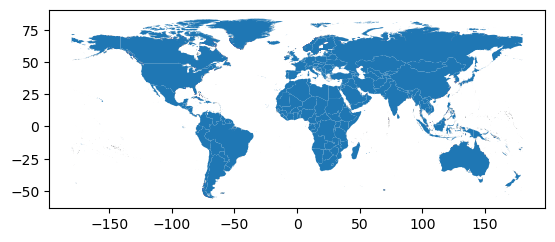

In [11]:
countries = gpd.read_file('https://github.com/geo-di-lab/emerge-lessons/raw/refs/heads/main/docs/data/world_countries.zip')[['COUNTRY', 'geometry']].to_crs(4326)
countries.plot()

Usaremos una [unión espacial](https://geopandas.org/en/stable/docs/reference/api/geopandas.sjoin.html) (`sjoin`) para obtener todos los datos que "intersecan" la capa de países, es decir, que están dentro de un país o sobre su límite.

In [12]:
data = gpd.sjoin(data, countries, how="inner", predicate='intersects') \
          .drop(columns=['index_right', 'COUNTRY']) \
          .reset_index(drop=True)

In [13]:
data

,CountryCode,CountryName,Elevation,AbdomenCloseupPhotoUrls,BreedingGroundEliminated,Comments,DataSource,ExtraData,Genus,GlobeTeams,LarvaFullBodyPhotoUrls,LarvaeCount,LastIdentifyStage,LocationAccuracyM,LocationMethod,MeasuredAt,MeasurementElevation,MeasurementLatitude,MeasurementLongitude,MosquitoAdults,MosquitoEggs,MosquitoHabitatMapperId,MosquitoPupae,Species,Userid,WaterSource,WaterSourcePhotoUrls,WaterSourceType,OrganizationId,OrganizationName,Protocol,SiteId,SiteName,geometry,MeasuredDate,LarvaeCountProcessed
0,BRA,Brazil,6.3,NaN,false,NaN,GLOBE Observer App,LarvaeVisibleNo,NaN,[COLUNSLZ],NaN,0,NaN,13,automatic,2024-12-31 17:16:00,0,-2.561700,-44.265700,NaN,NaN,46287,false,NaN,137422629,ovitrap,https://data.globe.gov/system/photos/2024/12/3...,container: artificial,17459532,Brazil Citizen Science,mosquito_habitat_mapper,371514,23MNT816168,POINT (-44.26597 -2.56197),2024-12-31,0.0
1,BRA,Brazil,6.3,NaN,false,NaN,GLOBE Observer App,LarvaeVisibleNo,NaN,[COLUNSLZ],NaN,0,NaN,13,automatic,2024-12-31 17:20:00,0,-2.561700,-44.265700,NaN,NaN,46290,false,NaN,137422629,ovitrap,https://data.globe.gov/system/photos/2024/12/3...,container: artificial,17459532,Brazil Citizen Science,mosquito_habitat_mapper,371514,23MNT816168,POINT (-44.26597 -2.56197),2024-12-31,0.0
2,BRA,Brazil,7.4,NaN,true,NaN,GLOBE Observer App,LarvaeVisibleNo,NaN,[COLUNSLZ],NaN,0,NaN,51,automatic,2024-12-31 22:32:00,0,-2.516300,-44.302300,NaN,NaN,46482,false,NaN,137420190,"cement, metal or plastic tank",NaN,container: artificial,17459532,Brazil Citizen Science,mosquito_habitat_mapper,372864,23MNT775218,POINT (-44.30288 -2.51676),2024-12-31,0.0
3,BRA,Brazil,20.6,NaN,true,NaN,GLOBE Observer App,LarvaeVisibleNo,NaN,[COLUNSLZ],NaN,0,NaN,66,automatic,2024-12-31 00:05:00,0,-2.863900,-44.054900,NaN,NaN,46203,false,NaN,137419937,can or bottle,NaN,container: artificial,17459532,Brazil Citizen Science,mosquito_habitat_mapper,373085,23MPS050834,POINT (-44.05526 -2.86396),2024-12-31,0.0
4,BRA,Brazil,20.6,NaN,true,NaN,GLOBE Observer App,LarvaeVisibleNo,NaN,[COLUNSLZ],NaN,0,NaN,28,automatic,2024-12-31 00:23:00,0,-2.863900,-44.055000,NaN,NaN,46223,false,NaN,137419937,lake,NaN,still: lake/pond/swamp,17459532,Brazil Citizen Science,mosquito_habitat_mapper,373085,23MPS050834,POINT (-44.05526 -2.86396),2024-12-31,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43007,ISR,Israel,714.0,NaN,false,بركة اصطناعية,GLOBE Observer App,NaN,NaN,None,NaN,1-25,identify-siphon-pecten,None,None,2018-01-08 12:14:00,714,33.010806,35.331531,false,false,1340,true,NaN,31782720,pond,https://data.globe.gov/system/photos/2018/01/0...,still: lake/pond/swamp,2567205,Horfish Elementary B School,mosquito_habitat_mapper,104220,36SYB178549,POINT (35.33153 33.01081),2018-01-08,13.0
43008,ISR,Israel,755.0,NaN,false,بركة اصطناعية من مياة الامطار,GLOBE Observer App,NaN,NaN,None,https://data.globe.gov/system/photos/2018/01/0...,1-25,identify-analyze-siphon,None,None,2018-01-07 10:53:00,755,33.013490,35.332672,false,false,1339,true,NaN,31782720,pond,https://data.globe.gov/system/photos/2018/01/0...,still: lake/pond/swamp,2567205,Horfish Elementary B School,mosquito_habitat_mapper,100667,36SYB179552,POINT (35.33267 33.01349),2018-01-07,13.0
43009,KOR,South Korea,287.5,NaN,false,NaN,GLOBE Observer App,NaN,NaN,None,NaN,NaN,NaN,None,None,2018-01-07 03:00:00,287.5,44.962525,-93.161031,NaN,NaN,1338,NaN,NaN,36916117,fountain or bird bath,https://data.globe.gov/system/photos/2018/01/0...,container: artificial,17479077,Republic of Korea Citizen Science,mosquito_habitat_mapper,104189,15TVK873788,POINT (-93.16103 44.96252),2018-01-07,NaN
43010,KOR,South Korea,287.5,NaN,false,NaN,GLOBE Observer App,NaN,NaN,None,NaN,0,identify-verify-larva,None,None,2018-01-05 03:00:00,287.5,44.962525,-93.161031,false,false,1337,false,NaN,36916117,well or cistern,https://data.globe.gov/system/photos/2018/01/0...,container: artificial,17479077,Repub

Hay una copia de este conjunto de datos [en GitHub](https://github.com/geo-di-lab/emerge-lessons/tree/main/docs/data), y la usaremos en capítulos posteriores. No necesitas descargar el conjunto de datos a tu computadora, ya que cargaremos los datos directamente mediante el enlace.

### Explora los datos

¡Hagamos un gráfico sencillo que muestre la cantidad de contribuciones enviadas por los científicos ciudadanos a lo largo del tiempo!

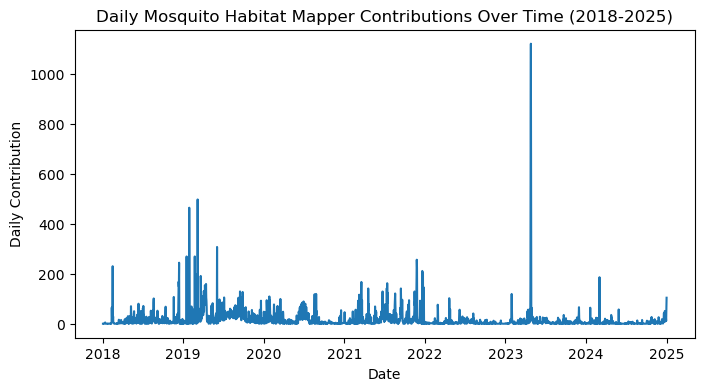

In [14]:
data_by_day = data[['SiteId', 'MeasuredDate']].groupby(['MeasuredDate'], as_index=False).count()

plt.figure(figsize=(8,4))
plt.plot(data_by_day['MeasuredDate'], data_by_day['SiteId'])
plt.xlabel("Fecha")
plt.ylabel("Contribuciones diarias")
plt.title("Contribuciones diarias a Mosquito Habitat Mapper a lo largo del tiempo (2018-2025)")
plt.show()

Grafiquemos la cantidad de contribuciones por país:

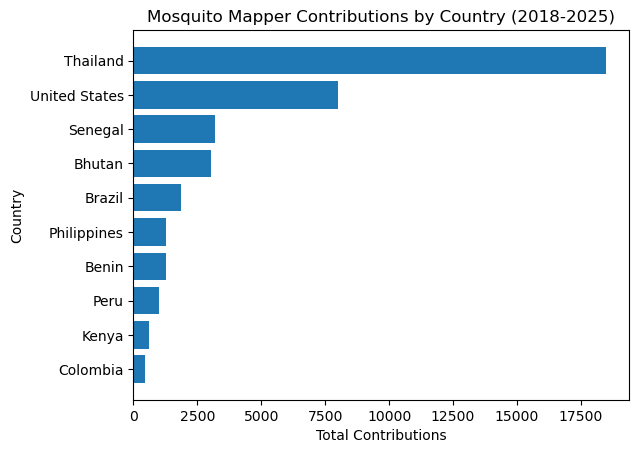

In [15]:
data_by_county = data[['SiteId', 'CountryName']].groupby(['CountryName'], as_index=False).count().sort_values(by='SiteId').tail(10)

plt.barh(data_by_county['CountryName'], data_by_county['SiteId'])
plt.xlabel("Contribuciones totales")
plt.ylabel("País")
plt.title("Contribuciones a Mosquito Mapper por país (2018-2025)")
plt.show()

## Land Cover

Ahora revisaremos el conjunto de datos de Land Cover. De forma similar, obtendremos los datos de la API de GLOBE usando el mismo rango de fechas que en el conjunto de datos de mosquitos.

In [16]:
data = gpd.read_file(f"https://api.globe.gov/search/v1/measurement/?protocols=land_covers&datefield=measuredDate&startdate=2018-01-01&enddate={end_date}&geojson=TRUE&sample=FALSE")

Observa la lista de columnas del conjunto de datos:

In [17]:
data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 52038 entries, 0 to 52037
Data columns (total 63 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   countryCode                     49631 non-null  object        
 1   countryName                     49631 non-null  object        
 2   elevation                       52038 non-null  object        
 3   landcoversDataSource            52038 non-null  object        
 4   landcoversDownwardCaption       52038 non-null  object        
 5   landcoversDownwardExtraData     52038 non-null  object        
 6   landcoversDownwardPhotoUrl      52038 non-null  object        
 7   landcoversDryGround             52038 non-null  object        
 8   landcoversEastCaption           52038 non-null  object        
 9   landcoversEastClassifications   52038 non-null  object        
 10  landcoversEastExtraData         52038 non-null  object        

In [18]:
# Quitemos el "landcovers" del inicio de todos los nombres de columna para verlos más fácilmente
new_column_names = data.columns.str.replace("landcovers", "")

# Pon en mayúscula la primera letra de cada nombre de columna (por consistencia), excepto en geometry
new_column_names = [name[0].upper() + name[1:] if name != 'geometry' else name for name in new_column_names]

data.columns = new_column_names
data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 52038 entries, 0 to 52037
Data columns (total 63 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   CountryCode           49631 non-null  object        
 1   CountryName           49631 non-null  object        
 2   Elevation             52038 non-null  object        
 3   DataSource            52038 non-null  object        
 4   DownwardCaption       52038 non-null  object        
 5   DownwardExtraData     52038 non-null  object        
 6   DownwardPhotoUrl      52038 non-null  object        
 7   DryGround             52038 non-null  object        
 8   EastCaption           52038 non-null  object        
 9   EastClassifications   52038 non-null  object        
 10  EastExtraData         52038 non-null  object        
 11  EastPhotoUrl          52038 non-null  object        
 12  Feature1Caption       52038 non-null  object        
 13  Feature1

In [19]:
# Agrega una nueva columna para la fecha
data['MeasuredDate'] = data['MeasuredAt'].dt.date

data.head(10)

,CountryCode,CountryName,Elevation,DataSource,DownwardCaption,DownwardExtraData,DownwardPhotoUrl,DryGround,EastCaption,EastClassifications,EastExtraData,EastPhotoUrl,Feature1Caption,Feature1ExtraData,Feature1PhotoUrl,Feature2Caption,Feature2ExtraData,Feature2PhotoUrl,Feature3Caption,Feature3ExtraData,Feature3PhotoUrl,Feature4Caption,Feature4ExtraData,Feature4PhotoUrl,FieldNotes,GlobeTeams,LandCoverId,LeavesOnTrees,LocationAccuracyM,LocationMethod,MeasuredAt,MeasurementElevation,MeasurementLatitude,MeasurementLongitude,MucCode,MucDescription,MucDetails,Muddy,NorthCaption,NorthClassifications,NorthExtraData,NorthPhotoUrl,RainingSnowing,SnowIce,SouthCaption,SouthClassifications,SouthExtraData,SouthPhotoUrl,StandingWater,UpwardCaption,UpwardExtraData,UpwardPhotoUrl,Userid,WestCaption,WestClassifications,WestExtraData,WestPhotoUrl,OrganizationId,OrganizationName,Protocol,SiteId,SiteName,geometry,MeasuredDate
0,ITA,Italy,489.2,GLOBE Observer App,null,null,https://data.globe.gov/system/photos/2024/12/3...,true,null,null,null,https://data.globe.gov/system/photos/2024/12/3...,"Snag C. sativa, 40 cm, cl 2, #01 #04 #12","((compassData.heading: 182, compassData.horizo...",https://data.globe.gov/system/photos/2024/12/3...,"Log 70 cm, C. sativa, cl 2, #04 #01 #12","((compassData.heading: 182, compassData.horizo...",https://data.globe.gov/system/photos/2024/12/3...,Stump of C. sativa 230 cm,"((compassData.heading: null, compassData.horiz...",https://data.globe.gov/system/photos/2024/12/3...,null,null,null,Old Coppice of Castanea sativa,[Conservazione Natura Universita Tuscia],78608,false,8,automatic,2024-12-31 15:07:00.000,492.4,42.1818,12.1825,null,null,,false,null,null,null,https://data.globe.gov/system/photos/2024/12/3...,false,false,null,null,null,https://data.globe.gov/system/photos/2024/12/3...,false,null,null,https://data.globe.gov/system/photos/2024/12/3...,128342138,null,null,null,https://data.globe.gov/system/photos/2024/12/3...,17453129,Italy Citizen Science,land_covers,376869,33TTG673738,POINT (12.18229 42.18175),2024-12-31
1,MDG,Madagascar,1350.1,GLOBE Observer App,null,null,https://data.globe.gov/system/photos/2024/12/3...,true,null,"90% MUC 01 (n) [Trees, Closely Spaced, Evergre...",null,https://data.globe.gov/system/photos/2024/12/3...,null,null,null,null,null,null,null,null,null,null,null,null,Arbres plantés par l'équipe GLOBE avec la comm...,"[Africa 2024 Regional Meeting, Coordinating Of...",77695,true,10,automatic,2024-12-31 11:29:00.000,1340.6,-18.7576,47.5615,M01,"Trees, Closely Spaced, Evergreen - Needle Leaved",n,false,null,"90% MUC 01 (n) [Trees, Closely Spaced, Evergre...",null,https://data.globe.gov/system/photos/2024/12/3...,false,false,null,"90% MUC 01 (n) [Trees, Closely Spaced, Evergre...",null,https://data.globe.gov/system/photos/2024/12/3...,false,null,null,https://data.globe.gov/system/photos/2024/12/3...,2538037,null,"90% MUC 01 (n) [Trees, Closely Spaced, Evergre...",null,https://data.globe.gov/system/photos/2024/12/3...,6508873,Madagascar GLOBE v-School,land_covers,373647,38KQE700240,POINT (47.56096 -18.75807),2024-12-31
2,MDG,Madagascar,1324.7,GLOBE Observer App,null,null,https://data.globe.gov/system/photos/2024/12/3...,true,null,"60% MUC 93 [Urban, Roads and Parking]",null,https://data.globe.gov/system/photos/2024/12/3...,null,null,null,null,null,null,null,null,null,null,null,null,(none),"[Africa 2024 Regional Meeting, Coordinating Of...",77691,true,10,automatic,2024-12-31 12:07:00.000,1324.8,-18.7944,47.5799,M93,"Urban, Roads and Parking",,false,null,"60% MUC 93 [Urban, Roads and Parking]",null,https://data.globe.gov/system/photos/2024/12/3...,false,false,null,"60% MUC 93 [Urban, Roads and Parking]",null,https://data.globe.gov/system/photos/2024/12/3...,false,null,null,https://data.globe.gov/system/photos/2024/12/3...,2538037,null,"60% MUC 93 [Urban, Roads and Parking]",null,https://data.globe.gov/system/photos/2024/12/3...,6508873,Madagascar GLOBE v-School,land_covers,373642,38KQE719199,POINT (47.579

Reemplaza los valores nulos:

In [20]:
data['FieldNotes'] = data['FieldNotes'].replace('(none)', np.nan)
data = data.replace('null', np.nan)

In [21]:
data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 52038 entries, 0 to 52037
Data columns (total 64 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   CountryCode           49631 non-null  object        
 1   CountryName           49631 non-null  object        
 2   Elevation             52038 non-null  object        
 3   DataSource            52038 non-null  object        
 4   DownwardCaption       22648 non-null  object        
 5   DownwardExtraData     22644 non-null  object        
 6   DownwardPhotoUrl      40040 non-null  object        
 7   DryGround             43973 non-null  object        
 8   EastCaption           23889 non-null  object        
 9   EastClassifications   14465 non-null  object        
 10  EastExtraData         23884 non-null  object        
 11  EastPhotoUrl          42897 non-null  object        
 12  Feature1Caption       341 non-null    object        
 13  Feature1

Al igual que con el conjunto de datos de mosquitos, filtraremos todos los puntos que no caigan dentro de los límites de los países. Si el punto está sobre el agua, asumimos que las coordenadas se reportaron de forma incorrecta y lo eliminamos del conjunto de datos final.

In [22]:
data = gpd.sjoin(data, countries, how="inner", predicate='intersects') \
          .drop(columns=['index_right', 'COUNTRY']) \
          .reset_index(drop=True)

In [23]:
data

,CountryCode,CountryName,Elevation,DataSource,DownwardCaption,DownwardExtraData,DownwardPhotoUrl,DryGround,EastCaption,EastClassifications,EastExtraData,EastPhotoUrl,Feature1Caption,Feature1ExtraData,Feature1PhotoUrl,Feature2Caption,Feature2ExtraData,Feature2PhotoUrl,Feature3Caption,Feature3ExtraData,Feature3PhotoUrl,Feature4Caption,Feature4ExtraData,Feature4PhotoUrl,FieldNotes,GlobeTeams,LandCoverId,LeavesOnTrees,LocationAccuracyM,LocationMethod,MeasuredAt,MeasurementElevation,MeasurementLatitude,MeasurementLongitude,MucCode,MucDescription,MucDetails,Muddy,NorthCaption,NorthClassifications,NorthExtraData,NorthPhotoUrl,RainingSnowing,SnowIce,SouthCaption,SouthClassifications,SouthExtraData,SouthPhotoUrl,StandingWater,UpwardCaption,UpwardExtraData,UpwardPhotoUrl,Userid,WestCaption,WestClassifications,WestExtraData,WestPhotoUrl,OrganizationId,OrganizationName,Protocol,SiteId,SiteName,geometry,MeasuredDate
0,ITA,Italy,489.2,GLOBE Observer App,NaN,NaN,https://data.globe.gov/system/photos/2024/12/3...,true,NaN,NaN,NaN,https://data.globe.gov/system/photos/2024/12/3...,"Snag C. sativa, 40 cm, cl 2, #01 #04 #12","((compassData.heading: 182, compassData.horizo...",https://data.globe.gov/system/photos/2024/12/3...,"Log 70 cm, C. sativa, cl 2, #04 #01 #12","((compassData.heading: 182, compassData.horizo...",https://data.globe.gov/system/photos/2024/12/3...,Stump of C. sativa 230 cm,"((compassData.heading: null, compassData.horiz...",https://data.globe.gov/system/photos/2024/12/3...,NaN,NaN,NaN,Old Coppice of Castanea sativa,[Conservazione Natura Universita Tuscia],78608,false,8,automatic,2024-12-31 15:07:00.000,492.4,42.1818,12.1825,NaN,NaN,,false,NaN,NaN,NaN,https://data.globe.gov/system/photos/2024/12/3...,false,false,NaN,NaN,NaN,https://data.globe.gov/system/photos/2024/12/3...,false,NaN,NaN,https://data.globe.gov/system/photos/2024/12/3...,128342138,NaN,NaN,NaN,https://data.globe.gov/system/photos/2024/12/3...,17453129,Italy Citizen Science,land_covers,376869,33TTG673738,POINT (12.18229 42.18175),2024-12-31
1,MDG,Madagascar,1350.1,GLOBE Observer App,NaN,NaN,https://data.globe.gov/system/photos/2024/12/3...,true,NaN,"90% MUC 01 (n) [Trees, Closely Spaced, Evergre...",NaN,https://data.globe.gov/system/photos/2024/12/3...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Arbres plantés par l'équipe GLOBE avec la comm...,"[Africa 2024 Regional Meeting, Coordinating Of...",77695,true,10,automatic,2024-12-31 11:29:00.000,1340.6,-18.7576,47.5615,M01,"Trees, Closely Spaced, Evergreen - Needle Leaved",n,false,NaN,"90% MUC 01 (n) [Trees, Closely Spaced, Evergre...",NaN,https://data.globe.gov/system/photos/2024/12/3...,false,false,NaN,"90% MUC 01 (n) [Trees, Closely Spaced, Evergre...",NaN,https://data.globe.gov/system/photos/2024/12/3...,false,NaN,NaN,https://data.globe.gov/system/photos/2024/12/3...,2538037,NaN,"90% MUC 01 (n) [Trees, Closely Spaced, Evergre...",NaN,https://data.globe.gov/system/photos/2024/12/3...,6508873,Madagascar GLOBE v-School,land_covers,373647,38KQE700240,POINT (47.56096 -18.75807),2024-12-31
2,MDG,Madagascar,1324.7,GLOBE Observer App,NaN,NaN,https://data.globe.gov/system/photos/2024/12/3...,true,NaN,"60% MUC 93 [Urban, Roads and Parking]",NaN,https://data.globe.gov/system/photos/2024/12/3...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[Africa 2024 Regional Meeting, Coordinating Of...",77691,true,10,automatic,2024-12-31 12:07:00.000,1324.8,-18.7944,47.5799,M93,"Urban, Roads and Parking",,false,NaN,"60% MUC 93 [Urban, Roads and Parking]",NaN,https://data.globe.gov/system/photos/2024/12/3...,false,false,NaN,"60% MUC 93 [Urban, Roads and Parking]",NaN,https://data.globe.gov/system/photos/2024/12/3...,false,NaN,NaN,https://data.globe.gov/system/photos/2024/12/3...,2538037,NaN,"60% MUC 93 [Urban, Roads and Parking]",NaN,https://data.globe.gov/system/photos/2024/12/3...,6508873,Madagascar GLOBE v-School,land_covers,373642,38KQE719199,POINT (47.57953 -18.79484),2024-12-31
3,USA,United States,182.2,GLOBE Data Entry Site

Al igual que los datos de mosquitos, hay una copia de este conjunto de datos [en GitHub](https://github.com/geo-di-lab/emerge-lessons/tree/main/docs/data), y la usaremos en capítulos posteriores. No necesitas descargar el conjunto de datos a tu computadora, ya que cargaremos los datos directamente mediante el enlace.

### Explora los datos

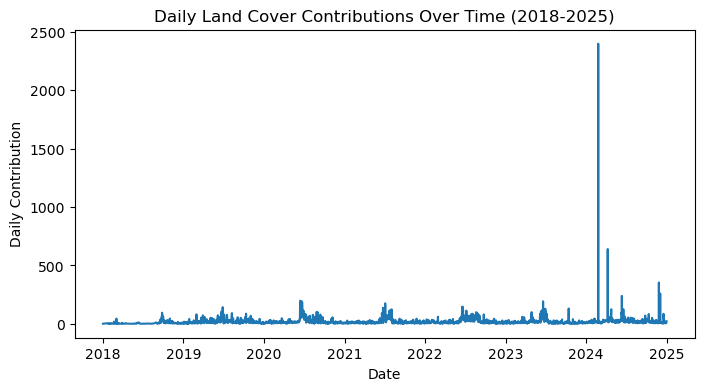

In [24]:
data_by_day = data[['SiteId', 'MeasuredDate']].groupby(['MeasuredDate'], as_index=False).count()

plt.figure(figsize=(8,4))
plt.plot(data_by_day['MeasuredDate'], data_by_day['SiteId'])
plt.xlabel("Fecha")
plt.ylabel("Contribuciones diarias")
plt.title("Contribuciones diarias a Land Cover a lo largo del tiempo (2018-2025)")
plt.show()

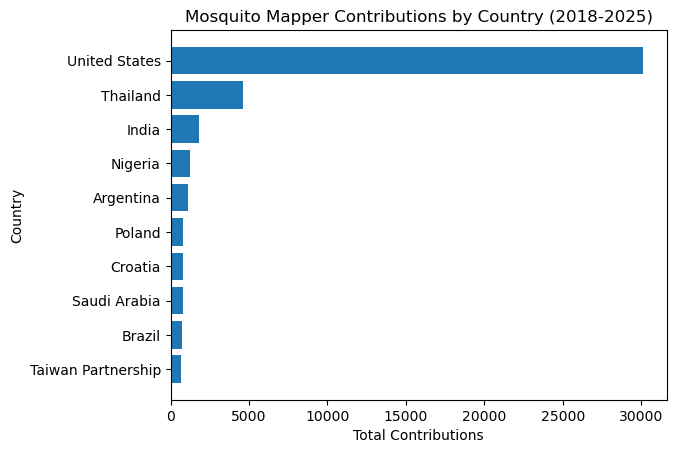

In [25]:
data_by_county = data[['SiteId', 'CountryName']].groupby(['CountryName'], as_index=False).count().sort_values(by='SiteId').tail(10)

plt.barh(data_by_county['CountryName'], data_by_county['SiteId'])
plt.xlabel("Contribuciones totales")
plt.ylabel("País")
plt.title("Contribuciones a Mosquito Mapper por país (2018-2025)")
plt.show()

Una característica valiosa del conjunto de datos de Land Cover es que las personas usuarias envían fotos del área. Veamos algunas de estas imágenes.

In [26]:
# Obtén la primera observación en la que se enviaron todas las fotos
entry = data.dropna(subset=['DownwardPhotoUrl', 'EastPhotoUrl', 'NorthPhotoUrl', 'SouthPhotoUrl', 'WestPhotoUrl', 'UpwardPhotoUrl',
                            'Feature1PhotoUrl', 'Feature2PhotoUrl', 'Feature3PhotoUrl', 'Feature4PhotoUrl']).head(1)

url_list = []
col_list = []

for col in entry.columns:
  if 'Url' in col:
    print(f'{col}: {entry[col].values[0]}')
    url_list.append(entry[col].values[0])
    col_list.append(col)

display(entry)

DownwardPhotoUrl: https://data.globe.gov/system/photos/2024/12/31/4325699/original.jpg
EastPhotoUrl: https://data.globe.gov/system/photos/2024/12/31/4325695/original.jpg
Feature1PhotoUrl: https://data.globe.gov/system/photos/2024/12/31/4325700/original.jpg
Feature2PhotoUrl: https://data.globe.gov/system/photos/2024/12/31/4325701/original.jpg
Feature3PhotoUrl: https://data.globe.gov/system/photos/2024/12/31/4325702/original.jpg
Feature4PhotoUrl: https://data.globe.gov/system/photos/2024/12/31/4325703/original.jpg
NorthPhotoUrl: https://data.globe.gov/system/photos/2024/12/31/4325694/original.jpg
SouthPhotoUrl: https://data.globe.gov/system/photos/2024/12/31/4325696/original.jpg
UpwardPhotoUrl: https://data.globe.gov/system/photos/2024/12/31/4325698/original.jpg
WestPhotoUrl: https://data.globe.gov/system/photos/2024/12/31/4325697/original.jpg


,CountryCode,CountryName,Elevation,DataSource,DownwardCaption,DownwardExtraData,DownwardPhotoUrl,DryGround,EastCaption,EastClassifications,EastExtraData,EastPhotoUrl,Feature1Caption,Feature1ExtraData,Feature1PhotoUrl,Feature2Caption,Feature2ExtraData,Feature2PhotoUrl,Feature3Caption,Feature3ExtraData,Feature3PhotoUrl,Feature4Caption,Feature4ExtraData,Feature4PhotoUrl,FieldNotes,GlobeTeams,LandCoverId,LeavesOnTrees,LocationAccuracyM,LocationMethod,MeasuredAt,MeasurementElevation,MeasurementLatitude,MeasurementLongitude,MucCode,MucDescription,MucDetails,Muddy,NorthCaption,NorthClassifications,NorthExtraData,NorthPhotoUrl,RainingSnowing,SnowIce,SouthCaption,SouthClassifications,SouthExtraData,SouthPhotoUrl,StandingWater,UpwardCaption,UpwardExtraData,UpwardPhotoUrl,Userid,WestCaption,WestClassifications,WestExtraData,WestPhotoUrl,OrganizationId,OrganizationName,Protocol,SiteId,SiteName,geometry,MeasuredDate
11,ITA,Italy,1076.2,GLOBE Observer App,NaN,NaN,https://data.globe.gov/system/photos/2024/12/3...,false,NaN,"90% MUC 12 (b) [Trees, Loosely Spaced, Deciduo...",NaN,https://data.globe.gov/system/photos/2024/12/3...,NaN,"((compassData.heading: 328, compassData.horizo...",https://data.globe.gov/system/photos/2024/12/3...,NaN,"((compassData.heading: 68, compassData.horizon...",https://data.globe.gov/system/photos/2024/12/3...,NaN,"((compassData.heading: 80, compassData.horizon...",https://data.globe.gov/system/photos/2024/12/3...,NaN,"((compassData.heading: 118, compassData.horizo...",https://data.globe.gov/system/photos/2024/12/3...,Buca in fustaia coetanea di faggio a dominanza...,[Conservazione Natura Universita Tuscia],78265,false,4,automatic,2024-12-31 10:47:00,1062.4,41.7648,14.2258,M12,"Trees, Loosely Spaced, Deciduous - Broad Leaved",b,false,NaN,"90% MUC 12 (b) [Trees, Loosely Spaced, Deciduo...",NaN,https://data.globe.gov/system/photos/2024/12/3...,false,true,NaN,"90% MUC 12 (b) [Trees, Loosely Spaced, Deciduo...",NaN,https://data.globe.gov/system/photos/2024/12/3...,false,NaN,NaN,https://data.globe.gov/system/photos/2024/12/3...,140413632,NaN,"90% MUC 12 (b) [Trees, Loosely Spaced, Deciduo...",NaN,https://data.globe.gov/system/photos/2024/12/3...,17453129,Italy Citizen Science,land_covers,375492,33TVG356239,POINT (14.22524 41.76432),2024-12-31


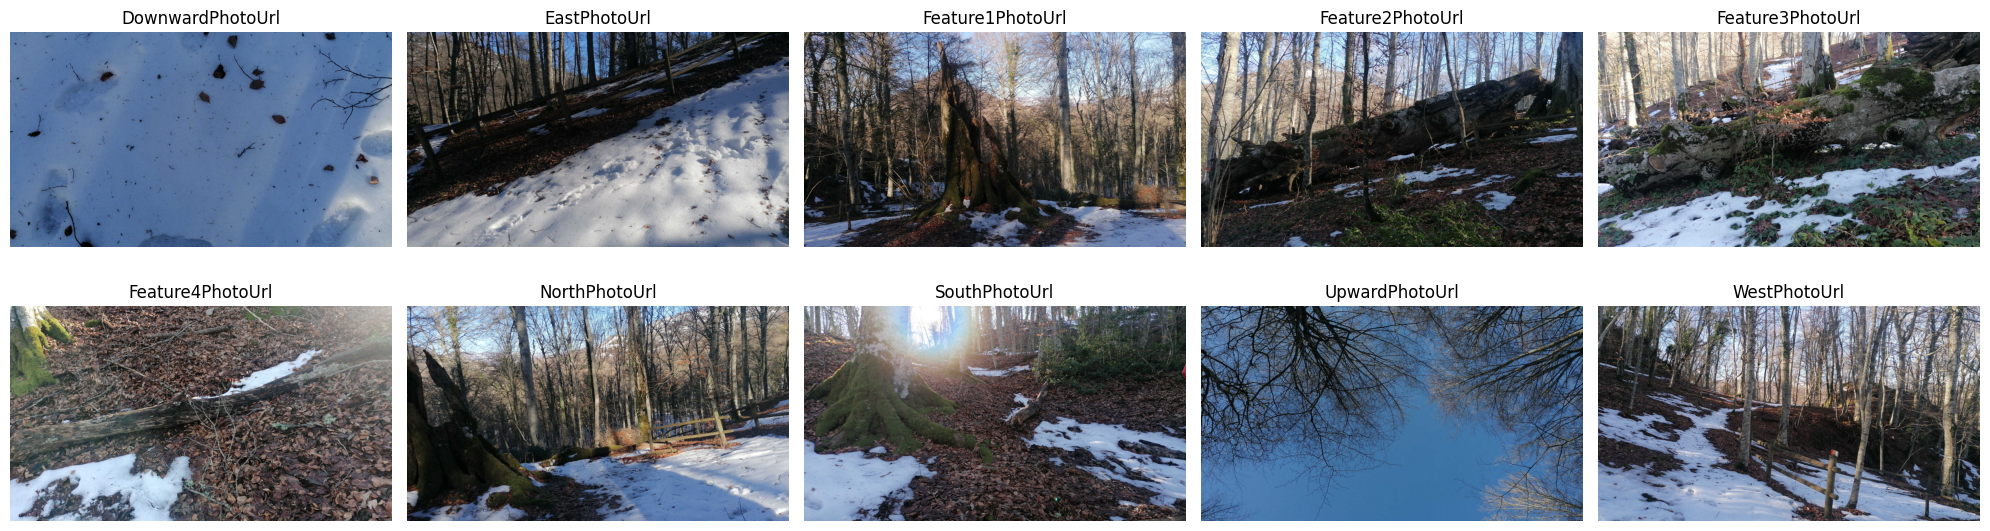

In [ ]:
# Grafica todas las imágenes
plt.figure(figsize=(20, 6))

for i, (url, title) in enumerate(zip(url_list, col_list)):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))

    # Crea el gráfico con 2 filas y 5 columnas
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()